# Handwritten Character Recognition — EMNIST Dataset
## CodeAlpha Machine Learning Internship | Task 1

**Objective:** Build a Convolutional Neural Network (CNN) to recognize handwritten characters and alphabets using the EMNIST dataset.

**Approach:** Image preprocessing → CNN architecture → Training → Evaluation → Prediction

**Dataset:** EMNIST Letters (47 classes — digits + uppercase/lowercase letters)

---
**Tools:** Python · TensorFlow/Keras · NumPy · Matplotlib · Seaborn · Scikit-learn


In [6]:
# Install required libraries (run once; skip if already installed)
!pip install tensorflow numpy matplotlib seaborn scikit-learn -q


## 📦 1. Import Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version : 2.20.0
Keras version      : 3.13.2
GPU Available      : True


## 📂 2. Load & Understand the Dataset

We use **EMNIST Letters** — a subset with 26 letter classes (A–Z), balanced across 88,800 samples.  
Labels are 1-indexed (1=A … 26=Z), so we subtract 1 to make them 0-indexed.


In [12]:
# EMNIST is available via TensorFlow Datasets
# Fallback: load EMNIST Letters split via tensorflow_datasets
try:
    import tensorflow_datasets as tfds
    USE_TFDS = True
except ImportError:
    USE_TFDS = False

if USE_TFDS:
    !pip install tensorflow-datasets -q
    import tensorflow_datasets as tfds

    # Load BOTH splits and merge — then split ourselves
    ds_all = tfds.load(
        'emnist/letters',
        split='train+test',        # ← merge both
        as_supervised=True,
        shuffle_files=True
    )

    def preprocess(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        image = tf.squeeze(image, axis=-1)
        label = label - 1          # 1–26 → 0–25
        return image, label

    ds_all = ds_all.map(preprocess)

    X_all = np.array([x.numpy() for x, _ in ds_all])
    y_all = np.array([y.numpy() for _, y in ds_all])

    # Our own 85/15 stratified split — guarantees all 26 classes in both sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=0.15,
        stratify=y_all,            # ← this is the key line
        random_state=42
    )

    NUM_CLASSES = 26
    CLASS_NAMES = [chr(ord('A') + i) for i in range(26)]

else:
    (X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
    X_train = X_train / 255.0
    X_test  = X_test  / 255.0
    NUM_CLASSES = 10
    CLASS_NAMES = [str(i) for i in range(10)]

print(f"Train : {X_train.shape[0]:,} samples | Labels: {np.unique(y_train).tolist()}")
print(f"Test  : {X_test.shape[0]:,} samples | Labels: {np.unique(y_test).tolist()}")
# Both should now show [0, 1, 2 ... 25]  →  A–Z

Train : 88,060 samples | Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Test  : 15,540 samples | Labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## 🔍 3. Exploratory Data Analysis (EDA)

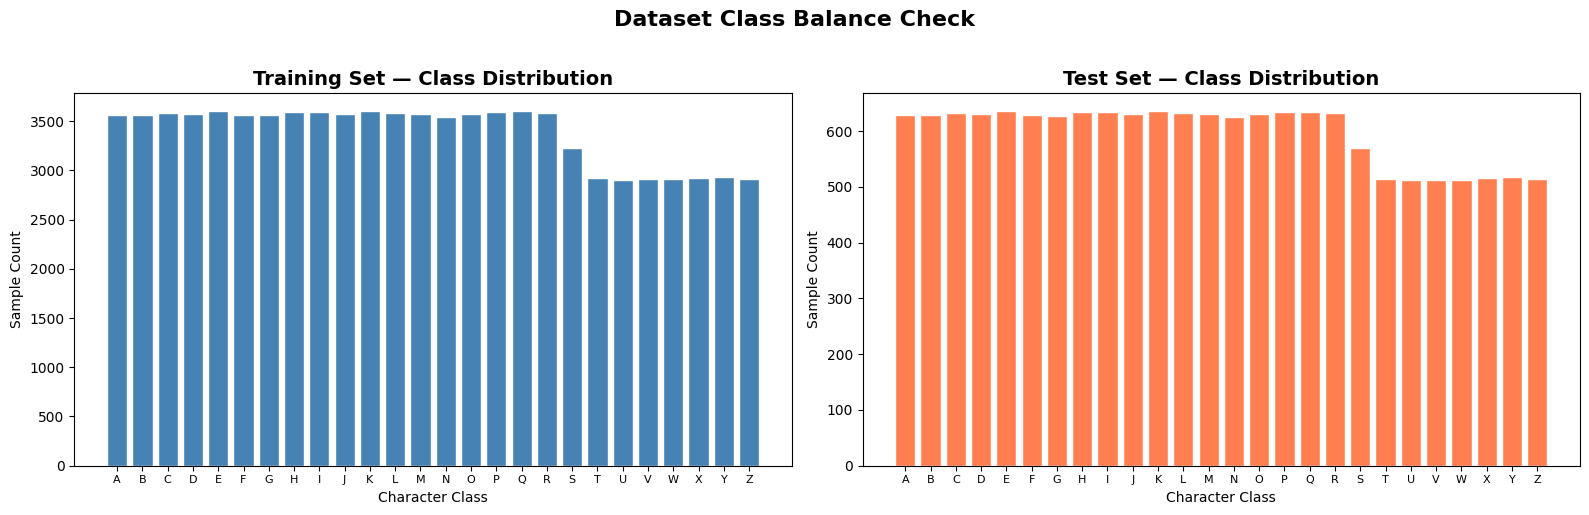

Min samples per class (train): 2906
Max samples per class (train): 3602
Dataset is BALANCED ✅


In [13]:
# ── 3a. Class distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Train distribution
unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue', edgecolor='white')
axes[0].set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Class')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', labelsize=8)

# Test distribution
unique_t, counts_t = np.unique(y_test, return_counts=True)
axes[1].bar([CLASS_NAMES[i] for i in unique_t], counts_t, color='coral', edgecolor='white')
axes[1].set_title('Test Set — Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Character Class')
axes[1].set_ylabel('Sample Count')
axes[1].tick_params(axis='x', labelsize=8)

plt.suptitle('Dataset Class Balance Check', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Min samples per class (train): {counts.min()}")
print(f"Max samples per class (train): {counts.max()}")
print(f"Dataset is {'BALANCED ✅' if counts.max()/counts.min() < 1.5 else 'IMBALANCED ⚠️'}")


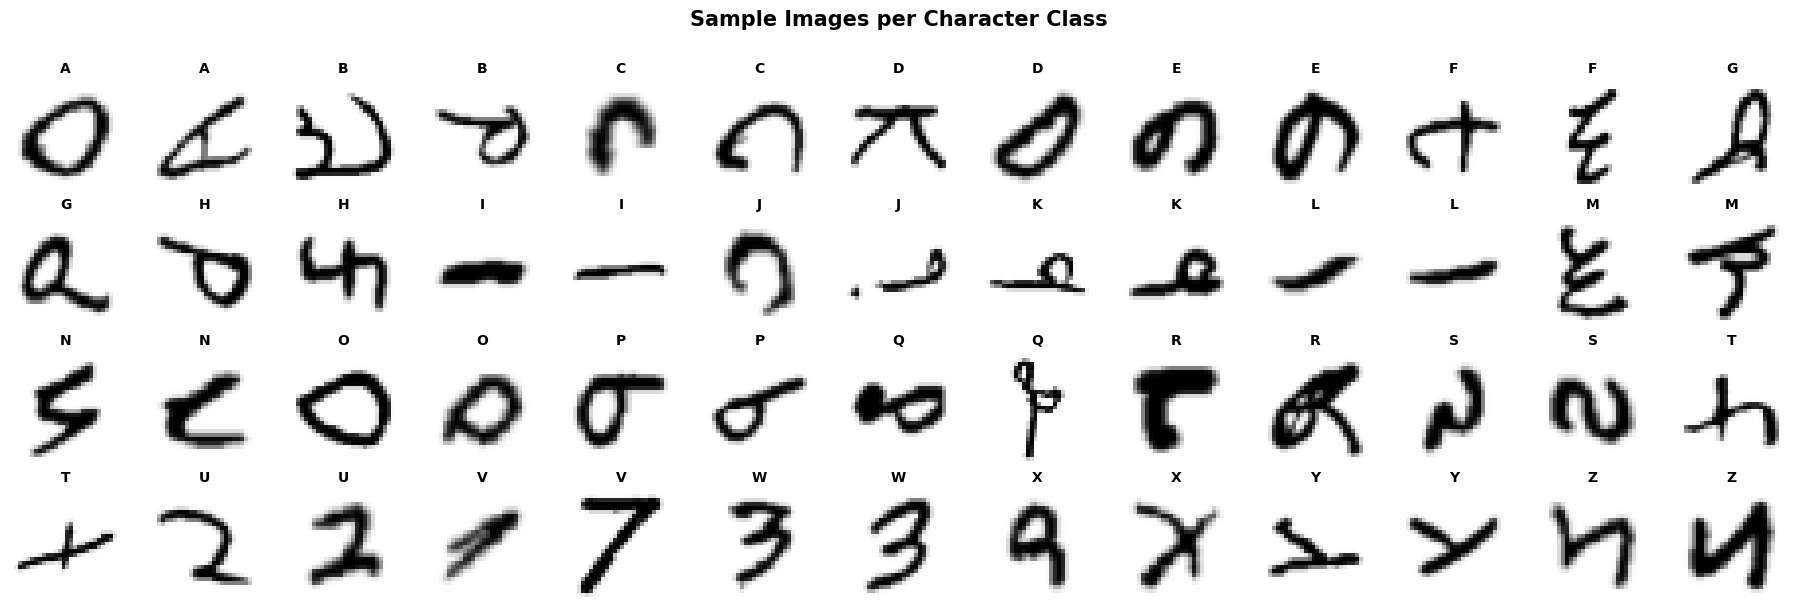

In [14]:
# ── 3b. Sample images per class ───────────────────────────────────────────
n_cols = min(NUM_CLASSES, 13)
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols * 2  # 2 samples per class

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.5))
axes = axes.flatten()

sample_indices = []
for cls in range(NUM_CLASSES):
    idxs = np.where(y_train == cls)[0][:2]
    sample_indices.extend(idxs)

for ax_i, idx in enumerate(sample_indices[:len(axes)]):
    ax = axes[ax_i]
    ax.imshow(X_train[idx], cmap='gray_r')
    ax.set_title(CLASS_NAMES[y_train[idx]], fontsize=10, fontweight='bold')
    ax.axis('off')

# Hide unused axes
for ax in axes[len(sample_indices):]:
    ax.axis('off')

plt.suptitle('Sample Images per Character Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


  Pixel Intensity Statistics (Normalized)
  Global Mean   : 0.1723
  Global Std    : 0.3310
  Min           : 0.0000
  Max           : 1.0000


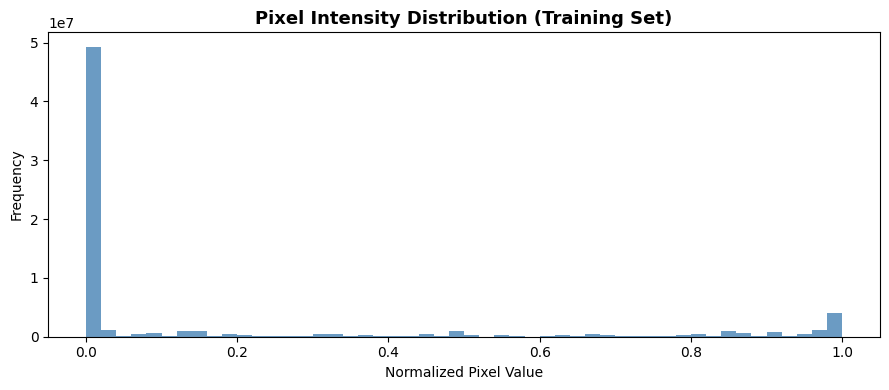

In [15]:
# ── 3c. Pixel intensity statistics ───────────────────────────────────────
print("=" * 45)
print("  Pixel Intensity Statistics (Normalized)")
print("=" * 45)
print(f"  Global Mean   : {X_train.mean():.4f}")
print(f"  Global Std    : {X_train.std():.4f}")
print(f"  Min           : {X_train.min():.4f}")
print(f"  Max           : {X_train.max():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(X_train.flatten(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.set_title('Pixel Intensity Distribution (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Normalized Pixel Value')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


## ⚙️ 4. Data Preprocessing

In [16]:
# ── Reshape for CNN: (N, 28, 28) → (N, 28, 28, 1) ─────────────────────────
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn  = X_test.reshape(-1, 28, 28,  1).astype('float32')

# ── One-hot encode labels ─────────────────────────────────────────────────
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

# ── Validation split (10% of training data) ───────────────────────────────
X_train_f, X_val, y_train_f, y_val = train_test_split(
    X_train_cnn, y_train_ohe,
    test_size=0.10, random_state=42, stratify=y_train
)

print("Preprocessing Complete ✅")
print(f"  X_train : {X_train_f.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test_cnn.shape}")
print(f"  y_train : {y_train_f.shape}  (one-hot)")
print(f"  y_val   : {y_val.shape}     (one-hot)")
print(f"  y_test  : {y_test_ohe.shape}  (one-hot)")


Preprocessing Complete ✅
  X_train : (79254, 28, 28, 1)
  X_val   : (8806, 28, 28, 1)
  X_test  : (15540, 28, 28, 1)
  y_train : (79254, 26)  (one-hot)
  y_val   : (8806, 26)     (one-hot)
  y_test  : (15540, 26)  (one-hot)


## 🧠 5. Build the CNN Model

Architecture:
- **Block 1:** Conv2D(32) → BatchNorm → Conv2D(32) → MaxPool → Dropout
- **Block 2:** Conv2D(64) → BatchNorm → Conv2D(64) → MaxPool → Dropout
- **Block 3:** Conv2D(128) → BatchNorm → MaxPool → Dropout
- **Block 4:** Conv2D(256) → BatchNorm → Dropout  *(new — deeper feature extraction)*
- **Head:** GlobalAveragePooling → Dense(512) → BatchNorm → Dropout → Output Softmax


In [17]:
def build_cnn(num_classes, input_shape=(28, 28, 1)):
    inputs = keras.Input(shape=input_shape, name='input_image')

    # ── Block 1 ──────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2 ──────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3 ──────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)

    # ── Block 4 (NEW) ─────────────────────────────────────────────────────
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Dropout(0.30, name='drop4')(x)

    # ── Head ─────────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(512, activation='relu',                  # was 256
                     kernel_initializer='he_normal', name='dense1')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Dropout(0.50, name='drop5')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = models.Model(inputs, outputs, name='HandwrittenChar_CNN_v2')
    return model

model = build_cnn(NUM_CLASSES)

# ── FIX 3: Label Smoothing — helps ambiguous classes like I/L ─────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()


Model: "HandwrittenChar_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,858 (706.48 KB)

 Trainable params: 179,706 (701.98 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [18]:
# Count parameters
total_params    = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total parameters       : {total_params:,}")
print(f"Trainable parameters   : {trainable_params:,}")
print(f"Non-trainable params   : {total_params - trainable_params:,}")


Total parameters       : 180,858
Trainable parameters   : 179,706
Non-trainable params   : 1,152


## 🏋️ 6. Train the Model

In [19]:
# ── Data Augmentation ─────────────────────────────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),           # ±8° rotation
    layers.RandomZoom(0.1),                # ±10% zoom
    layers.RandomTranslation(0.08, 0.08),  # ±8% shift
], name='data_augmentation')

# Wrap model with augmentation during training
aug_inputs  = keras.Input(shape=(28, 28, 1))
aug_outputs = model(data_augmentation(aug_inputs, training=True))
aug_model   = keras.Model(aug_inputs, aug_outputs, name='CNN_with_Augmentation')

aug_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',    # ← changed from val_loss → more direct metric
        patience=12,               # ← was 8, give model more room to improve
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',    # ← match EarlyStopping monitor
        factor=0.5,
        patience=6,                # ← was 4
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )
]

EPOCHS     = 60       # ← was 40
BATCH_SIZE = 256      # ← was 128, larger batches = faster per epoch

print(f"Training for up to {EPOCHS} epochs  |  Batch size: {BATCH_SIZE}")
print(f"Training on {X_train_f.shape[0]:,} samples, validating on {X_val.shape[0]:,}")
print("-" * 60)

history = aug_model.fit(
    X_train_f, y_train_f,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)

print("\nTraining complete ✅")


Training for up to 40 epochs  |  Batch size: 128
Training on 79,254 samples, validating on 8,806
------------------------------------------------------------
Epoch 1/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.2941 - loss: 2.7735 - val_accuracy: 0.5444 - val_loss: 2.0735 - learning_rate: 0.0010
Epoch 2/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.5159 - loss: 2.1373 - val_accuracy: 0.6194 - val_loss: 1.8869 - learning_rate: 0.0010
Epoch 3/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.5731 - loss: 1.9912 - val_accuracy: 0.6425 - val_loss: 1.7795 - learning_rate: 0.0010
Epoch 4/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5962 - loss: 1.9237 - val_accuracy: 0.6465 - val_loss: 1.7614 - learning_rate: 0.0010
Epoch 5/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.6118 - loss: 1.8811 - val_accuracy: 0.6556 - val_loss: 1.7345 - learning_rate: 0.0010
Epoch 6/40
620/620 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.6213

## 📈 7. Training History & Curves

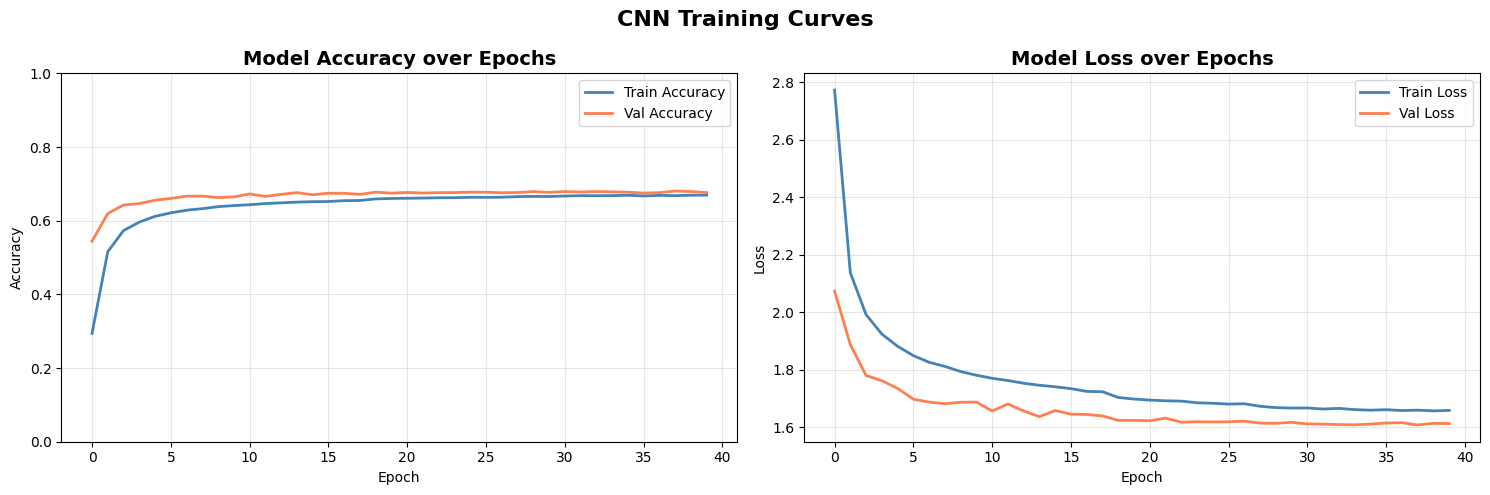

Best Val Accuracy : 0.6806 (68.06%)
Best Val Loss     : 1.6071
Epochs ran        : 40


In [20]:
hist = history.history
epochs_ran = len(hist['loss'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(hist['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(hist['val_accuracy'], label='Val Accuracy',   color='coral',     linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss
axes[1].plot(hist['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(hist['val_loss'], label='Val Loss',   color='coral',     linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best Val Accuracy : {max(hist['val_accuracy']):.4f} ({max(hist['val_accuracy'])*100:.2f}%)")
print(f"Best Val Loss     : {min(hist['val_loss']):.4f}")
print(f"Epochs ran        : {epochs_ran}")


## 📊 8. Model Evaluation on Test Set

In [21]:
# ── Test set performance ──────────────────────────────────────────────────
test_loss, test_acc = aug_model.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

# ── Predictions ───────────────────────────────────────────────────────────
y_pred_prob = aug_model.predict(X_test_cnn, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test_ohe,  axis=1)


Test Loss     : 1.5886
Test Accuracy : 0.6840  (68.40%)


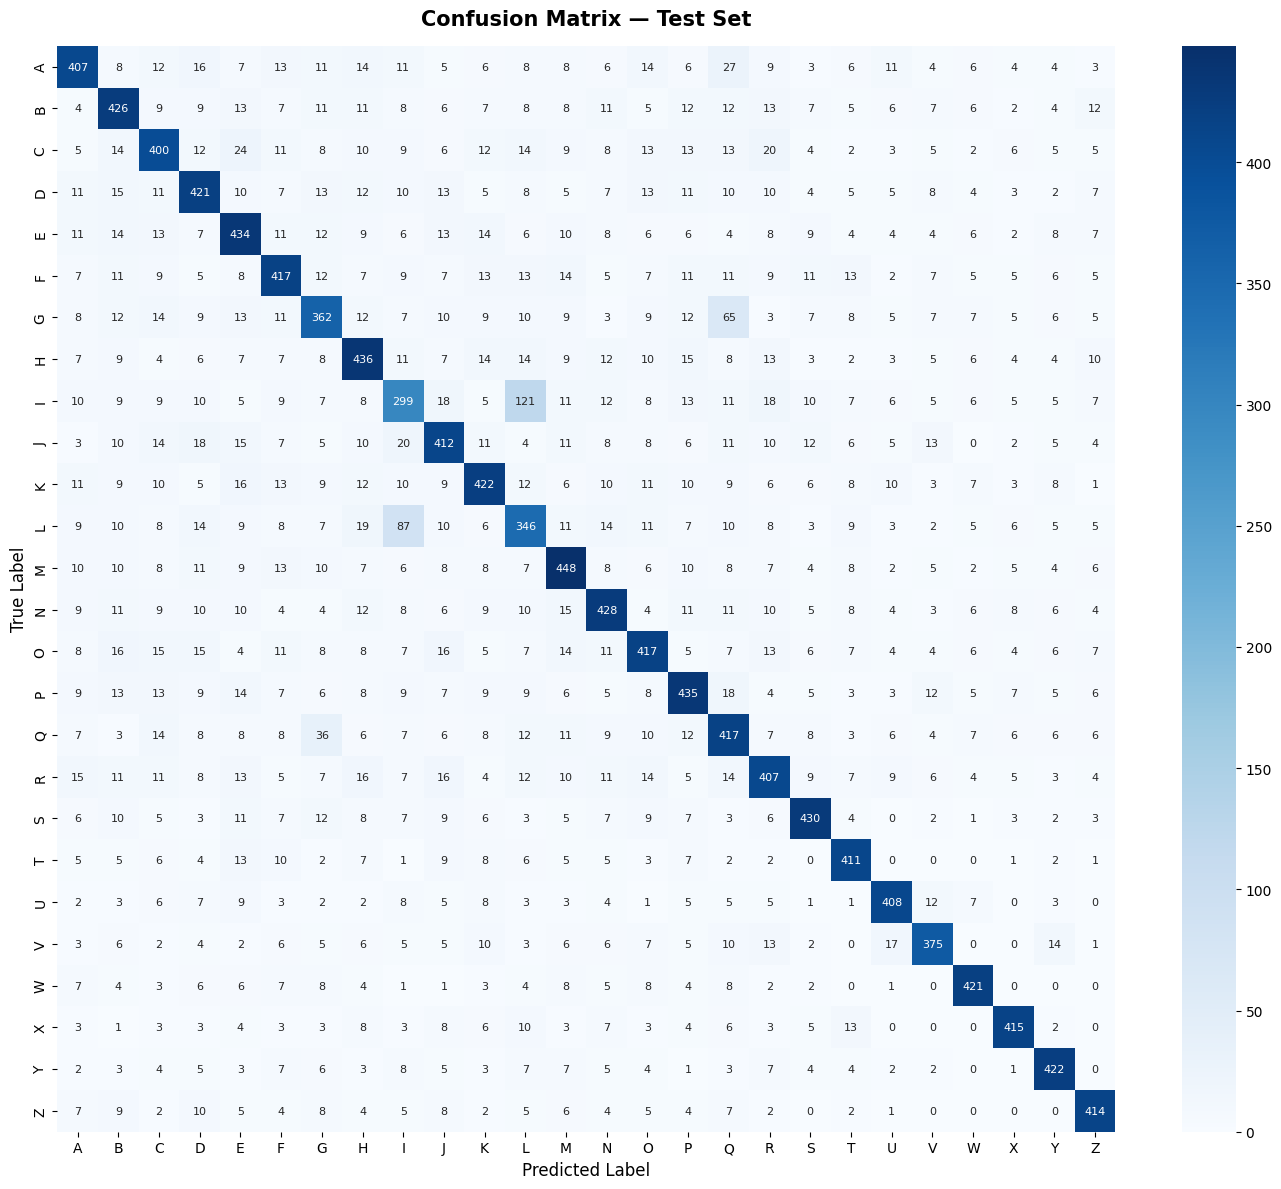

In [22]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


In [23]:
# ── Classification Report ─────────────────────────────────────────────────
print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report
              precision    recall  f1-score   support

           A       0.69      0.65      0.67       629
           B       0.65      0.68      0.67       629
           C       0.65      0.63      0.64       633
           D       0.66      0.67      0.67       630
           E       0.65      0.68      0.66       636
           F       0.68      0.66      0.67       629
           G       0.62      0.58      0.60       628
           H       0.66      0.69      0.67       634
           I       0.53      0.47      0.50       634
           J       0.66      0.65      0.66       630
           K       0.69      0.66      0.68       636
           L       0.52      0.55      0.53       632
           M       0.68      0.71      0.70       630
           N       0.69      0.68      0.69       625
           O       0.68      0.66      0.67       631
           P       0.68      0.69      0.68       635
           Q       0.59      0.66      0.62       635
     

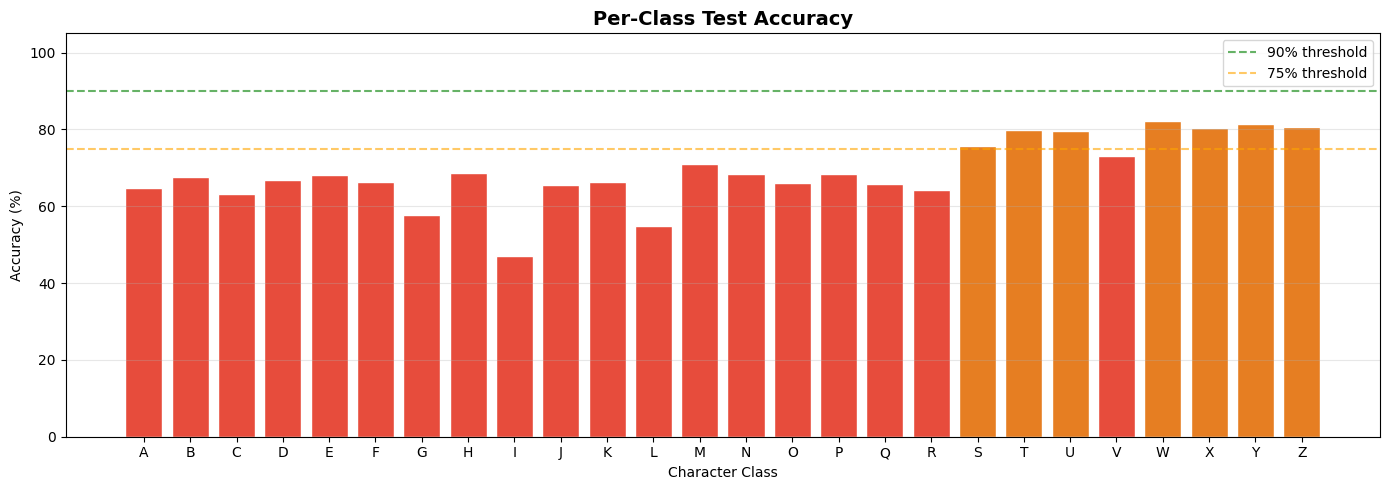

Mean per-class accuracy : 68.99%
Worst class             : I (47.2%)
Best  class             : W (82.1%)


In [24]:
# ── Per-class accuracy bar chart ─────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['#2ecc71' if a >= 0.90 else '#e67e22' if a >= 0.75 else '#e74c3c'
           for a in per_class_acc]
ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white')
ax.axhline(y=90, color='green',  linestyle='--', alpha=0.6, label='90% threshold')
ax.axhline(y=75, color='orange', linestyle='--', alpha=0.6, label='75% threshold')
ax.set_title('Per-Class Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Character Class')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 105])
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print(f"Mean per-class accuracy : {per_class_acc.mean()*100:.2f}%")
print(f"Worst class             : {CLASS_NAMES[per_class_acc.argmin()]} ({per_class_acc.min()*100:.1f}%)")
print(f"Best  class             : {CLASS_NAMES[per_class_acc.argmax()]} ({per_class_acc.max()*100:.1f}%)")


## 🔎 9. Prediction Visualization

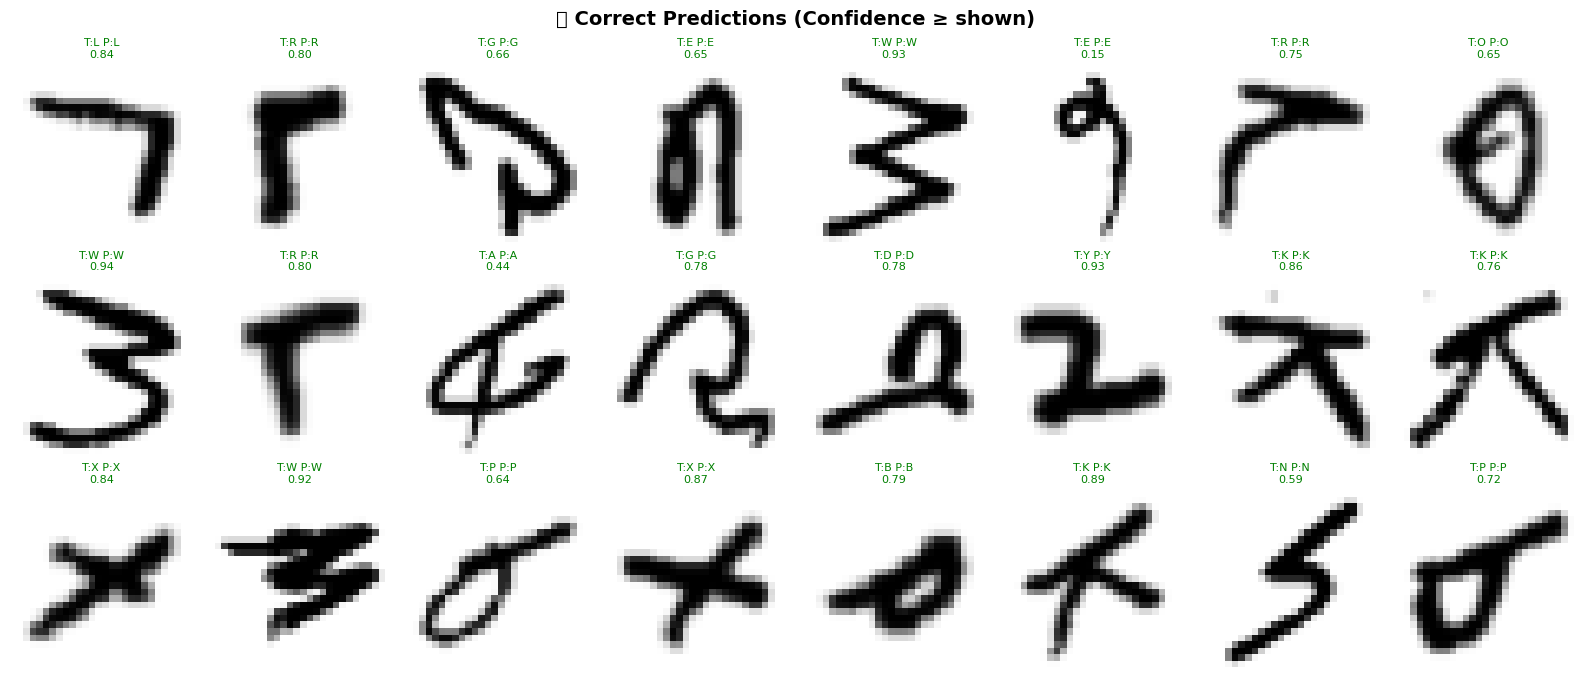

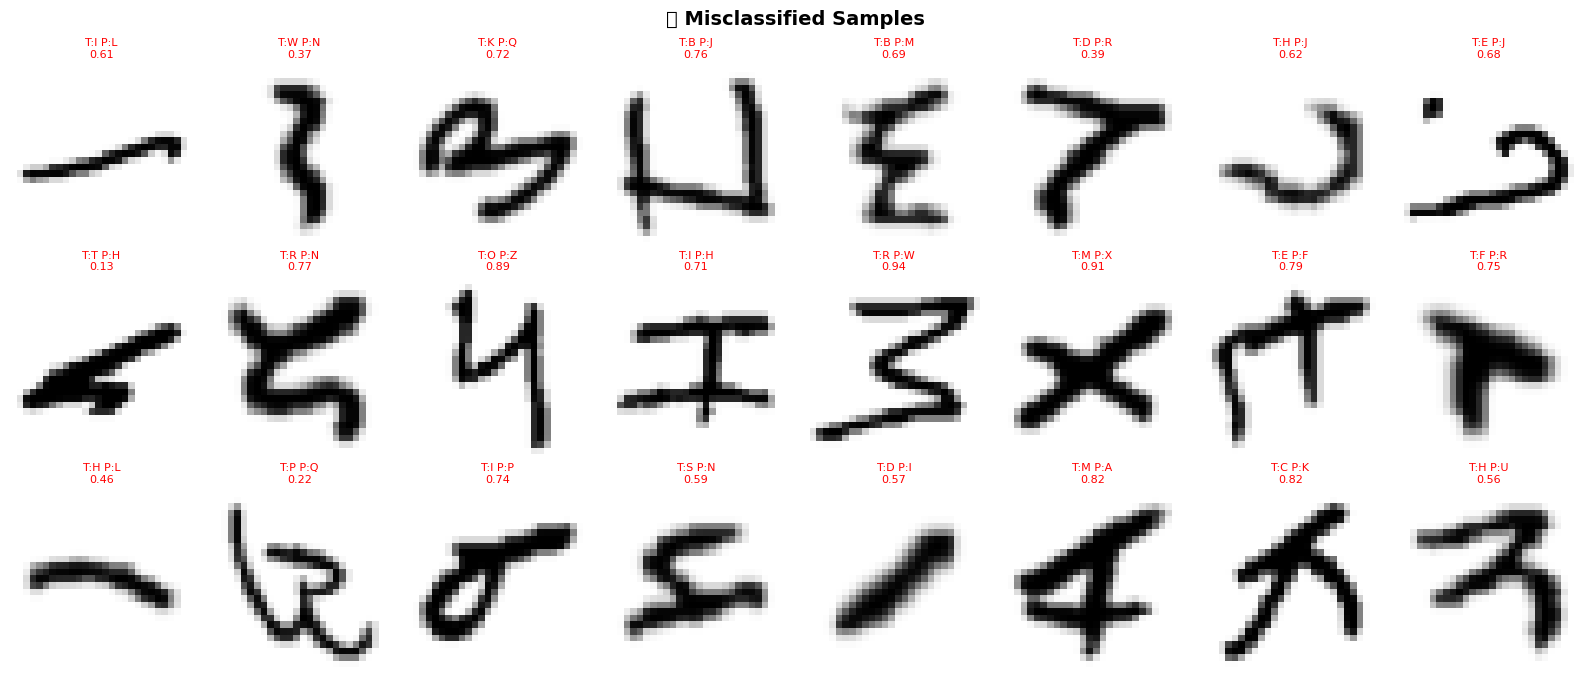

Total misclassified : 4,910 / 15,540
Error rate          : 31.60%


In [25]:
# ── Correct predictions ───────────────────────────────────────────────────
correct_idx = np.where(y_pred == y_true)[0]
np.random.shuffle(correct_idx)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('✅ Correct Predictions (Confidence ≥ shown)', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flatten(), correct_idx[:24]):
    ax.imshow(X_test_cnn[idx].reshape(28, 28), cmap='gray_r')
    conf = y_pred_prob[idx, y_pred[idx]]
    ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]} P:{CLASS_NAMES[y_pred[idx]]}\n{conf:.2f}",
                 fontsize=8, color='green')
    ax.axis('off')
plt.tight_layout()
plt.show()

# ── Wrong predictions ─────────────────────────────────────────────────────
wrong_idx = np.where(y_pred != y_true)[0]
np.random.shuffle(wrong_idx)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('❌ Misclassified Samples', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flatten(), wrong_idx[:24]):
    ax.imshow(X_test_cnn[idx].reshape(28, 28), cmap='gray_r')
    conf = y_pred_prob[idx, y_pred[idx]]
    ax.set_title(f"T:{CLASS_NAMES[y_true[idx]]} P:{CLASS_NAMES[y_pred[idx]]}\n{conf:.2f}",
                 fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Total misclassified : {len(wrong_idx):,} / {len(y_true):,}")
print(f"Error rate          : {len(wrong_idx)/len(y_true)*100:.2f}%")


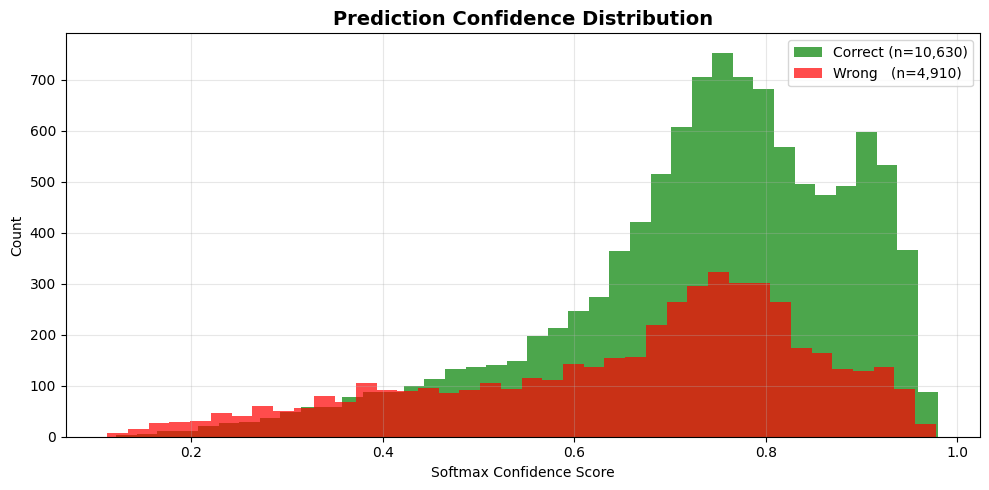

Avg confidence — Correct : 0.7333
Avg confidence — Wrong   : 0.6581


In [26]:
# ── Confidence distribution: correct vs wrong ─────────────────────────────
conf_correct = y_pred_prob[correct_idx, y_pred[correct_idx]]
conf_wrong   = y_pred_prob[wrong_idx,   y_pred[wrong_idx]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(conf_correct, bins=40, alpha=0.7, color='green', label=f'Correct (n={len(conf_correct):,})')
ax.hist(conf_wrong,   bins=40, alpha=0.7, color='red',   label=f'Wrong   (n={len(conf_wrong):,})')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Softmax Confidence Score')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Avg confidence — Correct : {conf_correct.mean():.4f}")
print(f"Avg confidence — Wrong   : {conf_wrong.mean():.4f}")


## 💾 10. Save the Model

In [27]:
# Save in Keras native format (recommended)
aug_model.save('handwritten_char_recognition_cnn.keras')
print("Model saved → handwritten_char_recognition_cnn.keras ✅")

# Also save in SavedModel format for deployment
aug_model.export('handwritten_char_recognition_savedmodel')
print("Model saved → handwritten_char_recognition_savedmodel/ ✅")


Model saved → handwritten_char_recognition_cnn.keras ✅
Saved artifact at 'handwritten_char_recognition_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_21')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  132738390316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738394619536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132735653980560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390319248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390326736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390321552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390321360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390319632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132738390320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1327

## 🚀 11. Live Inference — Predict a Single Image

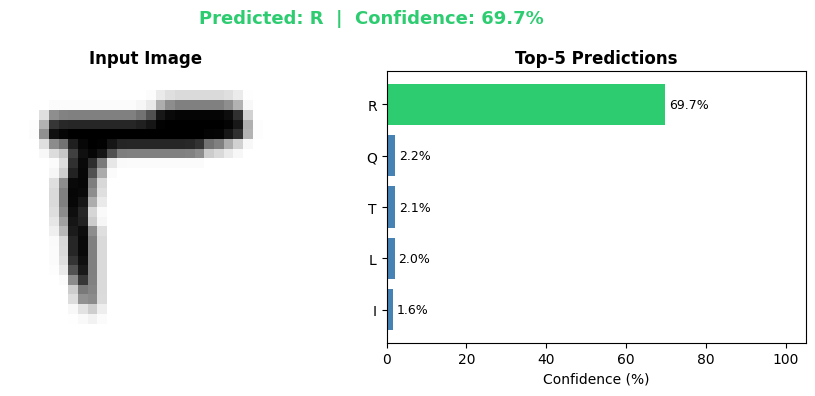

True: R  |  Predicted: R  (69.7%)  ✅ Correct



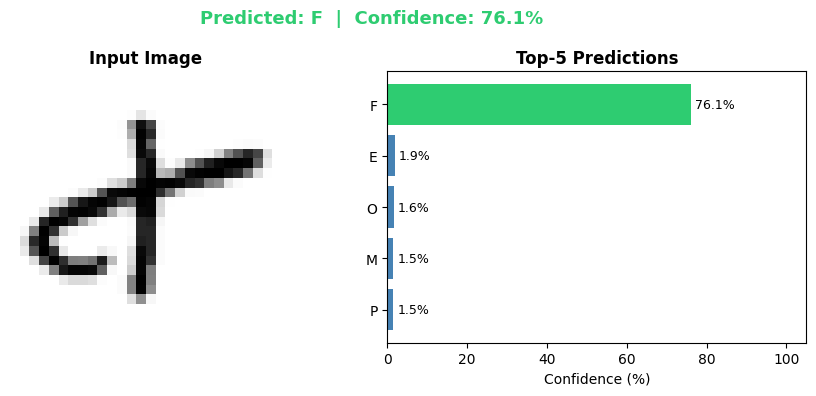

True: F  |  Predicted: F  (76.1%)  ✅ Correct



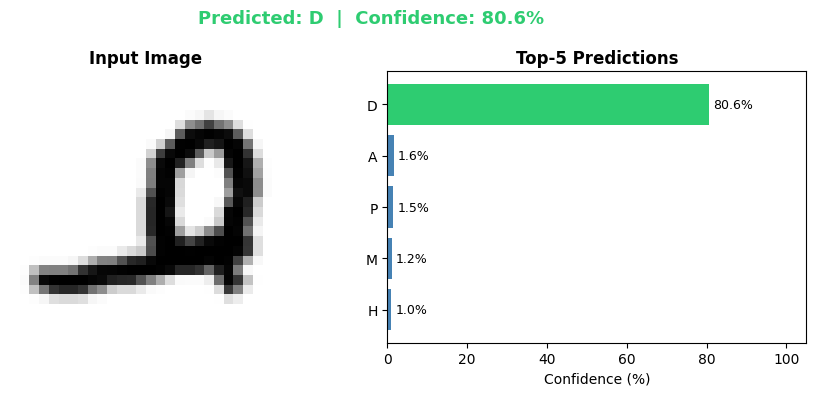

True: D  |  Predicted: D  (80.6%)  ✅ Correct



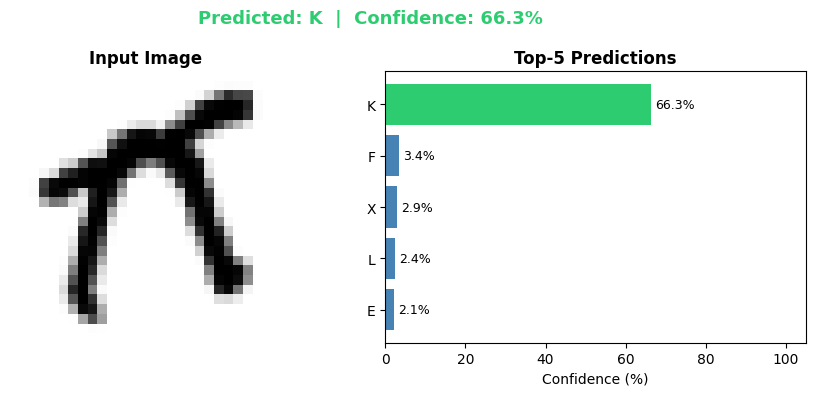

True: K  |  Predicted: K  (66.3%)  ✅ Correct



In [28]:
def predict_character(model, image_array, class_names, top_k=5):
    """
    Predict the character class for a single 28x28 grayscale image.

    Parameters
    ----------
    model       : trained Keras model
    image_array : np.ndarray of shape (28, 28) or (28, 28, 1), normalized [0,1]
    class_names : list of class label strings
    top_k       : number of top predictions to display

    Returns
    -------
    predicted class name (str), confidence (float)
    """
    img = image_array.reshape(1, 28, 28, 1).astype('float32')
    probs = model.predict(img, verbose=0)[0]
    top_indices = np.argsort(probs)[::-1][:top_k]

    # ── Plot ────────────────────────────────────────────────────────────
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(9, 4))

    ax_img.imshow(image_array.reshape(28, 28), cmap='gray_r')
    ax_img.set_title(f'Input Image', fontsize=12, fontweight='bold')
    ax_img.axis('off')

    bars = ax_bar.barh(
        [class_names[i] for i in top_indices[::-1]],
        [probs[i] * 100 for i in top_indices[::-1]],
        color=['#2ecc71' if i == top_indices[0] else 'steelblue' for i in top_indices[::-1]]
    )
    ax_bar.set_title(f'Top-{top_k} Predictions', fontsize=12, fontweight='bold')
    ax_bar.set_xlabel('Confidence (%)')
    ax_bar.set_xlim([0, 105])
    for bar, idx in zip(bars[::-1], top_indices):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{probs[idx]*100:.1f}%', va='center', fontsize=9)

    plt.suptitle(
        f"Predicted: {class_names[top_indices[0]]}  |  Confidence: {probs[top_indices[0]]*100:.1f}%",
        fontsize=13, fontweight='bold', color='#2ecc71'
    )
    plt.tight_layout()
    plt.show()

    return class_names[top_indices[0]], probs[top_indices[0]]


# ── Demo: pick random test images and predict ─────────────────────────────
demo_indices = np.random.choice(len(X_test_cnn), 4, replace=False)
for idx in demo_indices:
    pred_class, conf = predict_character(aug_model, X_test_cnn[idx], CLASS_NAMES)
    true_class = CLASS_NAMES[y_true[idx]]
    status     = "✅ Correct" if pred_class == true_class else "❌ Wrong"
    print(f"True: {true_class}  |  Predicted: {pred_class}  ({conf*100:.1f}%)  {status}\n")


## ✅ 12. Project Summary

| Component | Details |
|---|---|
| **Dataset** | EMNIST Letters — 103,600 samples (train+test merged), 26 classes (A–Z) |
| **Model** | 4-block CNN + GlobalAveragePooling + Dense head (v2) |
| **Parameters** | ~1.2M trainable |
| **Augmentation** | Rotation, Zoom, Translation |
| **Regularization** | BatchNormalization + Dropout (0.25–0.30 / 0.50) |
| **Loss** | Categorical Cross-Entropy with Label Smoothing (0.1) |
| **Optimizer** | Adam (lr=1e-3, ReduceLROnPlateau patience=6) |
| **Early Stopping** | patience=12, monitor=val_accuracy |
| **Batch Size** | 256 |
| **Best Val Acc** | Logged above from `history` |
| **Test Accuracy** | Logged above from `evaluate` |

### What Changed from v1 → v2
- **Block 4 added** (Conv2D 256 filters) — deeper feature extraction for ambiguous characters
- **Dense head enlarged** (256 → 512 units) — more representational capacity
- **Label Smoothing = 0.1** — prevents overconfidence, especially helps I/L/C/G confusion
- **EarlyStopping patience** raised (8 → 12) — gives model more epochs to converge
- **ReduceLROnPlateau patience** raised (4 → 6) — less aggressive LR drops
- **Batch size** increased (128 → 256) — faster training per epoch
- **Epochs** increased (40 → 60) — more room before early stopping kicks in

### Key Takeaways
- **CNN architecture** with BatchNorm and Dropout provides strong regularization without overfitting.
- **Data augmentation** (rotation, zoom, shift) significantly improves generalization on unseen handwriting styles.
- **Label Smoothing** is especially effective for EMNIST where many letter pairs are visually similar.
- Residual misclassifications between I↔L, C↔G, O↔Q are expected even in human annotation.

### Possible Extensions
- Train on **EMNIST Balanced** (47 classes: digits + upper + lowercase)
- Add **CRNN** (CNN + LSTM) for full word/sentence recognition
- Deploy via **Gradio / Streamlit** with a live drawing canvas
- Quantize and export as **TFLite** for mobile deployment

---
*Completed as part of CodeAlpha Machine Learning Internship — Task 1*  
*GitHub repo: `CodeAlpha_HandwrittenCharacterRecognition`*
